In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Extracted footprint directory (see analysis code for calculation)
footprint_on_dot6_motif_dir = "../Experimental_data_analysis/fimo_footprints/fig6/mnt_dot6_on_pac/raw_signals"

dot6_motif_pfm = "../pfm_others/pac_motif.pfm" # Available for download from from CISBP

## Imports

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import logomaker as lm

## Helper functions

In [4]:
# Return only position columns that exist in the dataframe
def _pos_cols_in(df, rng):
    cols = [f"pos_{i}" for i in rng]
    return [c for c in cols if c in df.columns]


# Sort rows by signal around the center and select a window of positions
def _sorted_and_window(df, width):
    if width < 1:
        raise ValueError("width must be >= 1")

    # columns used for sorting (centered region)
    sort_cols = _pos_cols_in(df, range(-25, 26))
    if len(sort_cols) == 0:
        raise ValueError("No sorting columns found (expected 'pos_-25'..'pos_25').")

    # sort rows by total signal near the center
    sort_sum = df[sort_cols].sum(axis=1)
    df_sorted = df.assign(_sum=sort_sum).sort_values("_sum", ascending=False).drop(columns="_sum")

    # columns used for plotting
    heat_cols = _pos_cols_in(df_sorted, range(-width, width + 1))
    if len(heat_cols) == 0:
        raise ValueError(f"No heatmap columns found for width={width}.")

    return df_sorted, heat_cols

## Plot

In [5]:
# Plot average signal across top promoters for multiple datasets
def plot_topN_average_line(dfs, labels, pfm_path):
    top_n = 200
    width = 75
    dropna = False
    figsize = (2.2, 4)

    fig = plt.figure(figsize=figsize)

    # layout: main plot + optional motif logo
    if pfm_path is None:
        ax = fig.add_subplot(111)
        ax_logo = None
    else:
        gs = GridSpec(2, 1, height_ratios=[3, 0.35], hspace=0.18, figure=fig)
        ax = fig.add_subplot(gs[0, 0])
        ax_logo = fig.add_subplot(gs[1, 0])

    colors = ("tab:blue", "tab:orange", "tab:green")

    # plot each dataset
    for df, label, color in zip(dfs, labels, colors):
        df_sorted, heat_cols = _sorted_and_window(df, width)

        if dropna:
            df_sorted = df_sorted.dropna(subset=heat_cols)

        # take top promoters and compute mean signal per position
        sub = df_sorted.iloc[:top_n][heat_cols]
        y = sub.mean(axis=0, skipna=True).to_numpy()

        xs = np.array([int(c.split("_")[1]) for c in heat_cols])
        ax.plot(xs, y, color=color, label=label, lw=1.5)

    # formatting
    ax.axvline(0, ls="--", alpha=0.2, color="black")
    ax.set_ylabel("Mean Signal", fontsize=11)
    ax.legend(loc="upper left", frameon=True, handlelength=0.8, handletextpad=0.2)

    # optional motif logo from PFM
    if ax_logo is not None:
        lines = [ln.strip() for ln in open(pfm_path) if ln.strip()]
        if lines[0].startswith(">"):
            lines = lines[1:]

        arr = np.array([list(map(float, ln.split())) for ln in lines])
        counts = pd.DataFrame(arr, columns=["A", "C", "G", "T"])

        probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
        ic = lm.transform_matrix(probs, from_type="probability", to_type="information")

        lm.Logo(ic, ax=ax_logo)

        # clean logo axis
        ax_logo.set_xticks([])
        ax_logo.set_yticks([])

        # adjust position to align nicely under plot
        pos = ax_logo.get_position()
        ax_logo.set_position([pos.x0 + 0.12, pos.y0, pos.width * 0.7, pos.height])

    fig.tight_layout()
    return fig

/tmp/ipykernel_3264515/4202867612.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


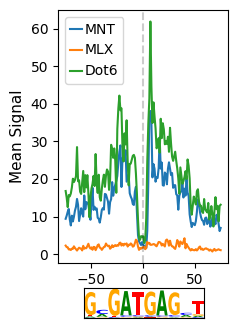

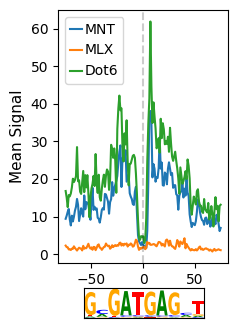

In [6]:
mnt_on_dot6 = pd.read_csv(f"{footprint_on_dot6_motif_dir}/MNT_raw_windows.csv", index_col=0)
mlx_on_dot6 = pd.read_csv(f"{footprint_on_dot6_motif_dir}/MLX_raw_windows.csv", index_col=0)
dot6_on_dot6 = pd.read_csv(f"{footprint_on_dot6_motif_dir}/Dot6_raw_windows.csv", index_col=0)

plot_topN_average_line(
    dfs=[mnt_on_dot6, mlx_on_dot6, dot6_on_dot6],
    labels=["MNT", "MLX", "Dot6"],
    pfm_path=dot6_motif_pfm,
)